In [ ]:
import pandas as pd
import re

In [ ]:
df = pd.read_csv("/content/youtube_comments_data.csv")

In [ ]:
# -------------------------
# Minimal Cleaning Function
# -------------------------
def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove extra spaces (optional but good)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

# Remove empty rows after cleaning
df = df[df["Cleaned_Comment"] != ""]
df.reset_index(drop=True, inplace=True)

print("Final shape:", df.shape)
df.head()

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)
    compound = score['compound']

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Comment"].apply(get_sentiment)

df["Sentiment"].value_counts()

,count
Sentiment,
Neutral,673
Positive,473
Negative,167


In [ ]:
# -----------------------------
# 1️⃣ Basic Counts
# -----------------------------
sentiment_counts = df["Sentiment"].value_counts()

neutral = sentiment_counts.get("Neutral", 0)
positive = sentiment_counts.get("Positive", 0)
negative = sentiment_counts.get("Negative", 0)

total = neutral + positive + negative

# -----------------------------
# 2️⃣ Percentages
# -----------------------------
neutral_pct = (neutral / total) * 100
positive_pct = (positive / total) * 100
negative_pct = (negative / total) * 100

print("Total Comments:", total)
print(f"Neutral: {neutral} ({neutral_pct:.2f}%)")
print(f"Positive: {positive} ({positive_pct:.2f}%)")
print(f"Negative: {negative} ({negative_pct:.2f}%)")

# -----------------------------
# 3️⃣ Engagement Metrics
# -----------------------------
# Assuming Like_Count and View_Count are same for all rows
likes = df["Like_Count"].iloc[0]
views = df["View_Count"].iloc[0]

like_view_ratio = (likes / views) * 100 if views != 0 else 0

print("\nLikes:", likes)
print("Views:", views)
print(f"Like/View Ratio: {like_view_ratio:.2f}%")

# -----------------------------
# 4️⃣ Verdict Logic
# -----------------------------
if negative_pct < 2:
    verdict = "Strongly Positive Reception"
elif negative_pct < 5:
    verdict = "Mostly Positive with Minor Criticism"
elif positive_pct > negative_pct:
    verdict = "Mixed but Leaning Positive"
else:
    verdict = "Negative / Controversial Reception"

print("\nFinal Verdict:", verdict)

Total Comments: 1313
Neutral: 673 (51.26%)
Positive: 473 (36.02%)
Negative: 167 (12.72%)

Likes: 20955
Views: 400227
Like/View Ratio: 5.24%

Final Verdict: Mixed but Leaning Positive


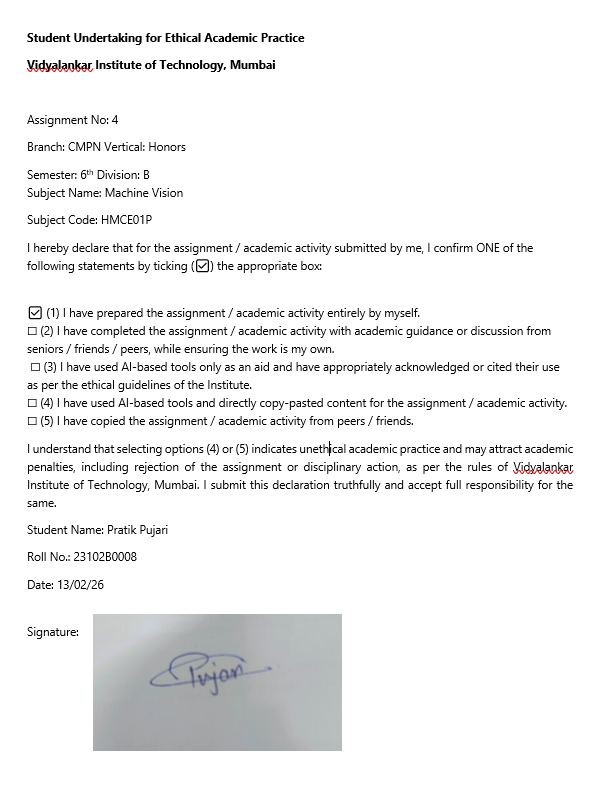